# Introduction Of the Project

This project performs customer segmentation using RFM analysis on an 
online retail dataset to understand purchasing behavior and identify high value customers.

In [1]:
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
#downloading dataset from kaggle
!kaggle datasets download -d mdsohailtanveer/online-retail-customer-segmentation


Dataset URL: https://www.kaggle.com/datasets/mdsohailtanveer/online-retail-customer-segmentation
License(s): unknown
online-retail-customer-segmentation.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
import shutil
shutil.unpack_archive("online-retail-customer-segmentation.zip",".")

In [5]:
# Renamed the file because of it's strange name.

In [18]:


df = pd.read_csv("Online Retail.xlsx - Online Retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# changes required from our observation:
  - Change the data type of Invoice Date (String to date and time)
  - Description contains missing values. Since it represents product names and is not required for RFM analysis,
    rows with missing descriptions may be removed.
  - CustomerID contains significant missing values; rows without CustomerID must be dropped for customer-level analysis.
  - Convert CustomerID to string after handling missing values, as it represents an identifier.

# DATA CLEANING

In [148]:
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    format="%m/%d/%Y %H:%M"
)

df['InvoiceDate'] = df['InvoiceDate'].dt.date

In [45]:
df['Description'].isna().sum()

1454

In [47]:
df=df.drop(columns='Description')

In [49]:
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [53]:
df['Country']=df['Country'].replace({
    "EIRE":"Ireland",
    "RSA":"South Africa"}
)
    

In [55]:
df=df.dropna(subset=["CustomerID"]).copy()

In [57]:
df.shape


(406829, 7)

In [59]:
df['CustomerID'].isna().sum().sum()

0

In [61]:
df['CustomerID']=df['CustomerID'].astype(str)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Quantity     406829 non-null  int64  
 3   InvoiceDate  406829 non-null  object 
 4   UnitPrice    406829 non-null  float64
 5   CustomerID   406829 non-null  object 
 6   Country      406829 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 24.8+ MB


In [65]:
df.describe()

,Quantity,UnitPrice
count,406829.000000,406829.000000
mean,12.061303,3.460471
std,248.693370,69.315162
min,-80995.000000,0.000000
25%,2.000000,1.250000
50%,5.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,38970.000000


In [67]:
df.head()

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [69]:
df.isna().sum().sum()

0

In [71]:
df.duplicated().sum()

5227

In [72]:
df['CustomerID']=df['CustomerID'].astype(float).astype(int).astype(str)

In [74]:
# Removed Invoices that were cancelled and Quantity which were less than 0

In [75]:
df[df["InvoiceNo"].str.startswith("C")].shape

(8905, 7)

In [78]:
df[df["Quantity"] < 0].shape

(8905, 7)

In [79]:
df=df[~df["InvoiceNo"].str.startswith("C")]
df=df[df['Quantity']>0].copy()

In [81]:
df[df["InvoiceNo"].str.startswith("C")].shape

(0, 7)

In [83]:
df[df["Quantity"] < 0].shape

(0, 7)

In [84]:
df[df.duplicated()].head(10)

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,1,12/1/10 11:45,1.25,17908,United Kingdom
527,536409,22866,1,12/1/10 11:45,2.10,17908,United Kingdom
537,536409,22900,1,12/1/10 11:45,2.95,17908,United Kingdom
539,536409,22111,1,12/1/10 11:45,4.95,17908,United Kingdom
555,536412,22327,1,12/1/10 11:49,2.95,17920,United Kingdom
587,536412,22273,1,12/1/10 11:49,2.95,17920,United Kingdom
589,536412,22749,1,12/1/10 11:49,3.75,17920,United Kingdom
594,536412,22141,1,12/1/10 11:49,2.10,17920,United Kingdom
598,536412,21448,1,12/1/10 11:49,1.65,17920,United Kingdom
600,536412,22569,2,12/1/10 11:49,3.75,17920,United Kingdom


In [86]:
df[df.duplicated()].shape

(5194, 7)

In [87]:
dup = df[df.duplicated(keep=False)]
dup.head(10)

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,1,12/1/10 11:45,4.95,17908,United Kingdom
489,536409,22866,1,12/1/10 11:45,2.10,17908,United Kingdom
494,536409,21866,1,12/1/10 11:45,1.25,17908,United Kingdom
517,536409,21866,1,12/1/10 11:45,1.25,17908,United Kingdom
521,536409,22900,1,12/1/10 11:45,2.95,17908,United Kingdom
527,536409,22866,1,12/1/10 11:45,2.10,17908,United Kingdom
537,536409,22900,1,12/1/10 11:45,2.95,17908,United Kingdom
539,536409,22111,1,12/1/10 11:45,4.95,17908,United Kingdom
548,536412,22327,1,12/1/10 11:49,2.95,17920,United Kingdom
555,536412,22327,1,12/1/10 11:49,2.95,17920,United Kingdom


In [89]:
df = df.drop_duplicates().copy()

In [91]:
df.duplicated().sum()

0

In [92]:
#What time period does the data cover?

In [94]:
start_date=df['InvoiceDate'].min()
end_date=df['InvoiceDate'].max()
print(f"Time Period {start_date} to {end_date}")



Time Period 1/10/11 10:32 to 9/9/11 9:52


In [95]:
#How many unique customers are in the dataset?

In [96]:
df.nunique()

InvoiceNo      18536
StockCode       3665
Quantity         302
InvoiceDate    17286
UnitPrice        441
CustomerID      4339
Country           37
dtype: int64

In [98]:
# What is the total revenue generated?

In [99]:
df['Total Revenue']=df['Quantity']*df['UnitPrice']
Total_revenue=df['Total Revenue'].sum()
print(f"Total Revenue Generated: ${Total_revenue}")

Total Revenue Generated: $8886657.043999998


In [100]:
#How often do customers make purchases?

In [102]:
frequency=df.groupby('CustomerID')['InvoiceNo'].nunique()
print(f"Frequency of Customer's Purchases: {frequency}")

Frequency of Customer's Purchases: CustomerID
12346     1
12347     7
12348     4
12349     1
12350     1
         ..
18280     1
18281     1
18282     2
18283    16
18287     3
Name: InvoiceNo, Length: 4339, dtype: int64


In [103]:
#How much do customers spend on average?

In [104]:
customer_spend=df.groupby('CustomerID')['Total Revenue'].sum().mean().round(2)

print("Average Customer Spend:",customer_spend)

Average Customer Spend: 2048.09


In [106]:
#recent purchase per customer

In [107]:
recent_pur=df.groupby('CustomerID')['InvoiceDate'].max()
recent_pur.sort_values(ascending=False)

CustomerID
17593      9/9/11 9:52
13441      9/9/11 9:38
12449      9/9/11 9:13
16173      9/9/11 9:03
12535      9/9/11 8:48
             ...      
15346    1/11/11 11:18
13144    1/11/11 11:15
16351    1/11/11 10:26
15326    1/10/11 11:38
16850    1/10/11 11:09
Name: InvoiceDate, Length: 4339, dtype: object

In [108]:
#which customers purchase most frequently?

In [111]:
frequency=df.groupby('CustomerID')['InvoiceNo'].nunique()
frequency.sort_values(ascending=False)

CustomerID
12748    210
14911    201
17841    124
13089     97
14606     93
        ... 
14355      1
13403      1
15488      1
14353      1
12346      1
Name: InvoiceNo, Length: 4339, dtype: int64

In [114]:
df.head()

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total Revenue
0,536365,85123A,6,12/1/10 8:26,2.55,17850,United Kingdom,15.30
1,536365,71053,6,12/1/10 8:26,3.39,17850,United Kingdom,20.34
2,536365,84406B,8,12/1/10 8:26,2.75,17850,United Kingdom,22.00
3,536365,84029G,6,12/1/10 8:26,3.39,17850,United Kingdom,20.34
4,536365,84029E,6,12/1/10 8:26,3.39,17850,United Kingdom,20.34


In [115]:
#Which customers spend the most money?

In [119]:
most_spend=df.groupby('CustomerID')['Total Revenue'].sum()
most_spend=most_spend.sort_values(ascending=False)
print(most_spend.head(10))

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: Total Revenue, dtype: float64


# RFM

- Creating a RFM table, We calculate Recency,Frequency,Monetary for each customer 

In [150]:
snapshot_date=df["InvoiceDate"].max()+pd.Timedelta(1)
rfm=df.groupby('CustomerID').agg({
    'InvoiceDate':lambda x:(snapshot_date-x.max()).days,
    'InvoiceNo':'nunique',
    'Total Revenue':'sum'
})
rfm.columns=['Recency','Frequency','Monetary']

In [152]:
print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346           325          1  77183.60
12347             2          7   4310.00
12348            75          4   1797.24
12349            18          1   1757.55
12350           310          1    334.40


- Creating a RFM ScoreCard

In [164]:
rfm['R']=pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1])
rfm['F']=pd.qcut(rfm['Frequency'].rank(method='first'),5,labels=[1,2,3,4,5])
rfm['M']=pd.qcut(rfm['Monetary'],5,labels=[1,2,3,4,5])


- Creating a segment Code

In [ ]:
rfm['RFM_score']=rfm['R'].astype(str)+rfm['F'].astype(str)+rfm['M'].astype(str)

In [ ]:
rfm['RFM_score']

In [170]:
rfm['RF_score']=rfm['R'].astype(str)+rfm['F'].astype(str)

In [172]:
segment_map={
    r'[5][4-5]':'Champions',
    r'[4][4-5]':'Loyal Customers',
    r'[3][3-5]':'Potential Loyalist',
    r'[5][1-3]':'New Customers',
    r'[4][1-2]':'Promising Customers',
    r'[3][1-2]':'Needs Attention',
    r'[2][2-3]':'About to sleep',
    r'[1-2][4-5]':'At Risk',
    r'[1][1-3]':'Lost Customers'
}
rfm['Segment']=rfm['RF_score'].replace(segment_map,regex=True)
rfm.loc[rfm['Segment'].str.isnumeric(),'Segment']='Others'



In [ ]:
#How Many Customers Fall Into RFM Segment

In [174]:
rfm['Segment'].value_counts()

Segment
Lost Customers         802
Champions              633
Potential Loyalist     511
Loyal Customers        495
About to sleep         438
Others                 375
Needs Attention        352
At Risk                284
New Customers          235
Promising Customers    214
Name: count, dtype: int64

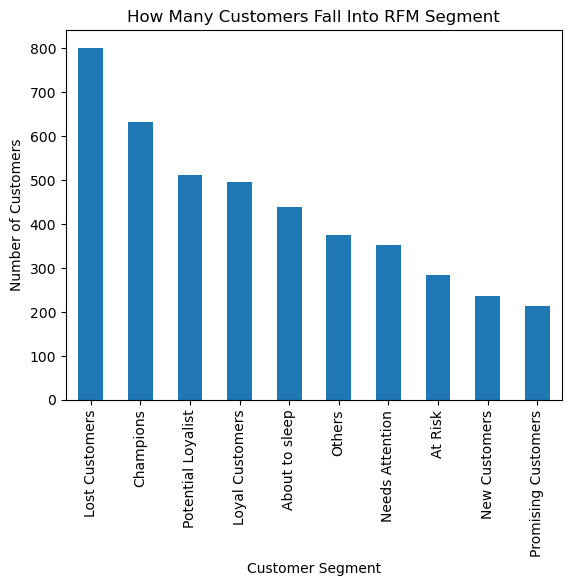

In [176]:
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("How Many Customers Fall Into RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.show()

In [178]:
#Which segment contributes the highest revenue?

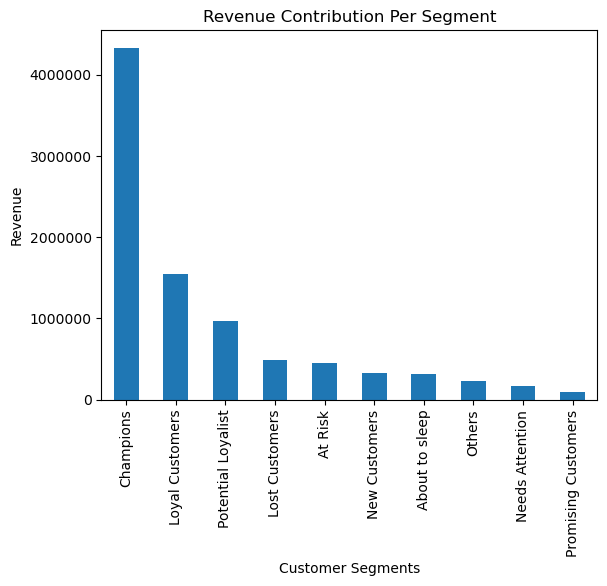

In [182]:
revenue_by_segment=rfm.groupby('Segment')['Monetary'].sum()
revenue_by_segment=revenue_by_segment.sort_values(ascending=False)

revenue_by_segment.plot(kind='bar')
plt.title("Revenue Contribution Per Segment")
plt.xlabel("Customer Segments")
plt.ylabel("Revenue")
plt.ticklabel_format(style='plain', axis='y')
plt.show()



In [184]:
#Which customers are at risk of churn?

In [187]:
rfm[rfm['Segment']=='At Risk'].shape[0]

284

Customers classified in the "At Risk" segment are likely to churn. These customers previously made frequent purchases or
generated significant revenue but have not made a purchase recently. 
They represent an important group for targeted marketing campaigns such as discounts, reminders, or personalized offers to re-engage them

In [190]:
#How does spending differ across customer segments?

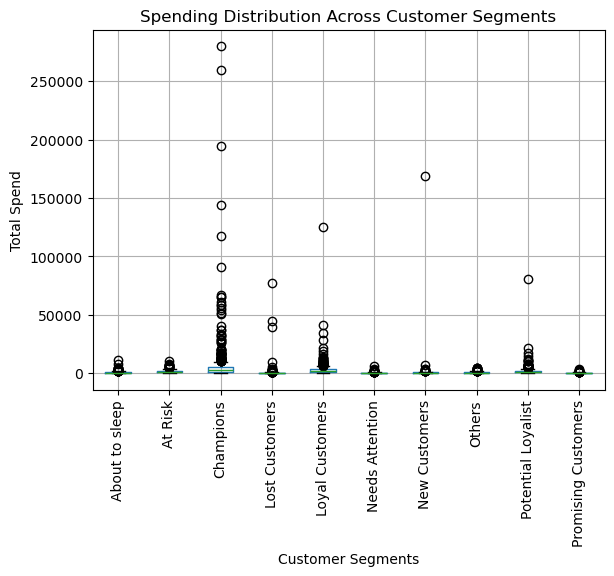

In [206]:
rfm.boxplot(column='Monetary',by='Segment')
plt.title("Spending Distribution Across Customer Segments")
plt.suptitle("")
plt.xlabel("Customer Segments")
plt.xticks(rotation=90)
plt.ylabel("Total Spend")
plt.show()

In [208]:
#How does purchase frequency differ across segments?

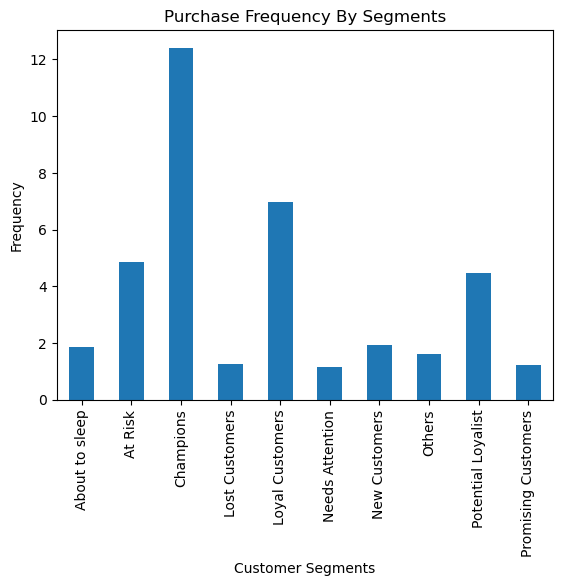

In [214]:
frequency_by_segment=rfm.groupby('Segment')['Frequency'].mean()
frequency_by_segment.plot(kind='bar')

plt.title("Purchase Frequency By Segments")
plt.xlabel("Customer Segments")
plt.ylabel("Frequency")

plt.show()

# Conclusion

- Champions customer segment generate the highest revenue
- Champions and Loyal Customers are the most frequent purchasers 
- At risk customers require re-engagement campaigns
